In [1]:
!pip install uproot
import uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.5/397.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.2/924.2 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 41.8 MB/s eta 0:00:00


using test root

Viking.mac:
/control/verbose 0

/control/execute /users/mw2304/geant4_apps/QEPET/build/quiet.mac

/process/em/QuantumEntanglement true

/run/numberOfThreads 1

'# To enable 3-gamma annihilations
'#/process/em/setPositronAtRestModel OrePowellPolar'

'#/material/g4/ortoPositroniumFraction G4_AIR 1.0

'#/material/g4/ortoPositroniumFraction G4_WATER 1.0

'#/material/g4/ortoPositroniumFraction G4_BONE_COMPACT_ICRU 1.0

'# Activate/deactivate non-collinearity
/QEPET/det/nonCollin false

/control/execute /users/mw2304/geant4_apps/QEPET/build/randomTissues.mac

/run/initialize

/control/execute /users/mw2304/geant4_apps/QEPET/build/randomSources.mac

/run/beamOn 100000


In [2]:
import matplotlib.pyplot as plt

rootfile = uproot.open('test.root')
print(rootfile.keys())

['NCS;1', 'PhantomSCS;1', 'ScannerSCS;1', 'PhantomSCS_ScannerSCS;1', 'PhantomDCS;1', 'ScannerDCS;1', 'PhantomSCS_ScannerDCS;1', 'PhantomDCS_ScannerSCS;1', 'PhantomDCS_ScannerDCS;1', 'MCS;1', 'Excluded;1']


In [3]:
tree = rootfile["NCS"]

print(tree.num_entries)

4218.0


In [4]:
for key in rootfile.keys():
    obj = rootfile[key]
    if hasattr(obj, "num_entries"):
        print(key, obj.num_entries)

NCS;1 4218.0
PhantomSCS;1 1844.0
ScannerSCS;1 9299.0
PhantomSCS_ScannerSCS;1 3015.0
PhantomDCS;1 157.0
ScannerDCS;1 5288.0
PhantomSCS_ScannerDCS;1 1102.0
PhantomDCS_ScannerSCS;1 166.0
PhantomDCS_ScannerDCS;1 40.0
MCS;1 0.0
Excluded;1 0.0


In [5]:
tree = rootfile['NCS']
print(tree.keys())

['AnnihilX', 'AnnihilY', 'AnnihilZ', 'Gamma1_ScatterX', 'Gamma1_ScatterY', 'Gamma1_ScatterZ', 'Gamma1_Theta', 'Gamma1_HitE1', 'Gamma1_HitX1', 'Gamma1_HitY1', 'Gamma1_HitZ1', 'Gamma1_HitE2', 'Gamma1_HitX2', 'Gamma1_HitY2', 'Gamma1_HitZ2', 'Gamma2_ScatterX', 'Gamma2_ScatterY', 'Gamma2_ScatterZ', 'Gamma2_Theta', 'Gamma2_HitE1', 'Gamma2_HitX1', 'Gamma2_HitY1', 'Gamma2_HitZ1', 'Gamma2_HitE2', 'Gamma2_HitX2', 'Gamma2_HitY2', 'Gamma2_HitZ2', 'DeltaPhi']


In [6]:
x = tree["AnnihilX"].array(library="np")

print(type(x))
print(len(x))
print(x[:10])

<class 'numpy.ndarray'>
4218
[-1.0355828   2.528145    4.5318255   1.666726    3.7932696   2.8061187
  0.29709366  1.5279022   3.3034244   5.127826  ]


anhilation X posiiton histogram

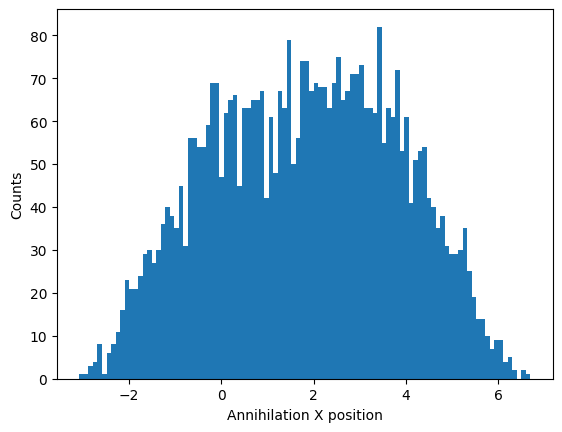

In [7]:
plt.hist(x, bins=100)
plt.xlabel("Annihilation X position")
plt.ylabel("Counts")
plt.show()

Anhilation distrbution

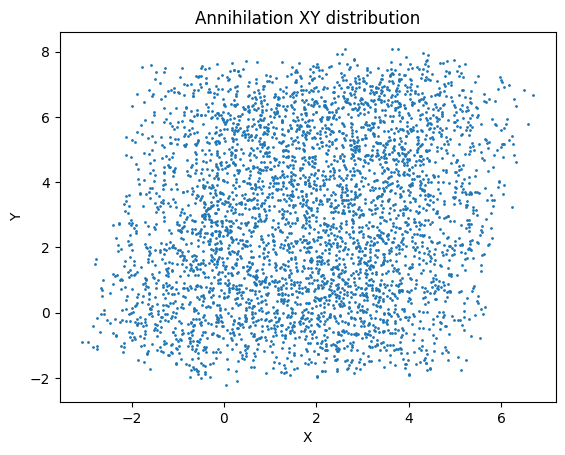

In [8]:
x = tree["AnnihilX"].array()
y = tree["AnnihilY"].array()

plt.scatter(x, y, s=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Annihilation XY distribution")
plt.show()

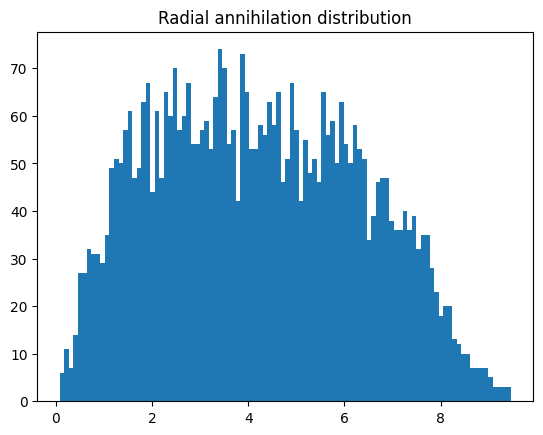

In [10]:
import numpy as np
r = np.sqrt(x**2 + y**2)

plt.hist(r, bins=100)
plt.title("Radial annihilation distribution")
plt.show()

broader distribution - extended source

z slice

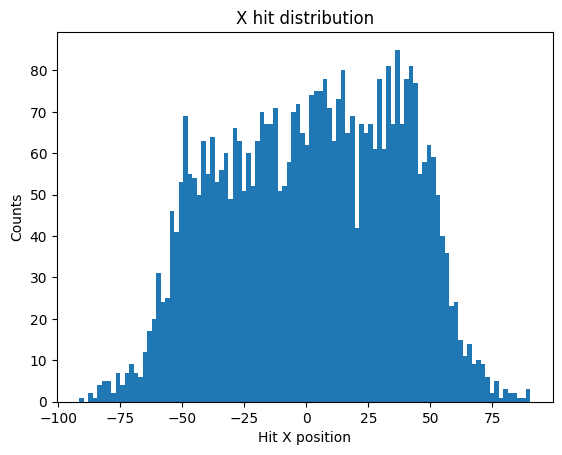

In [11]:
x = tree["Gamma1_HitX1"].array(library="np")

plt.hist(x, bins=100)
plt.xlabel("Hit X position")
plt.ylabel("Counts")
plt.title("X hit distribution")
plt.show()

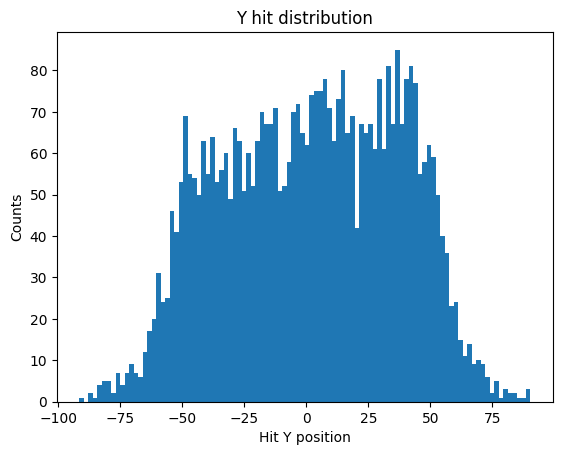

In [12]:
Y = tree["Gamma1_HitY1"].array(library="np")

plt.hist(x, bins=100)
plt.xlabel("Hit Y position")
plt.ylabel("Counts")
plt.title("Y hit distribution")
plt.show()

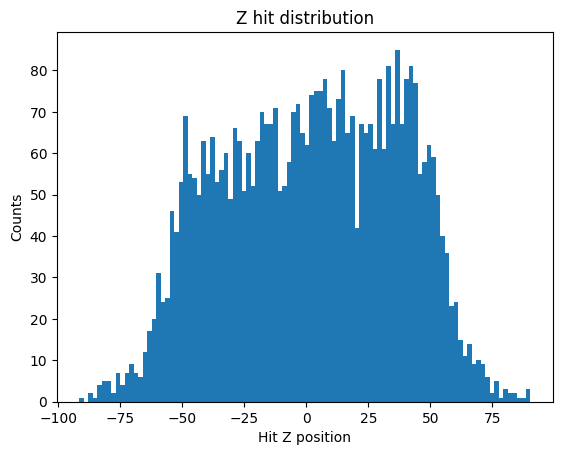

In [13]:
Z = tree["Gamma1_HitZ1"].array(library="np")

plt.hist(x, bins=100)
plt.xlabel("Hit Z position")
plt.ylabel("Counts")
plt.title("Z hit distribution")
plt.show()

energy spectrum

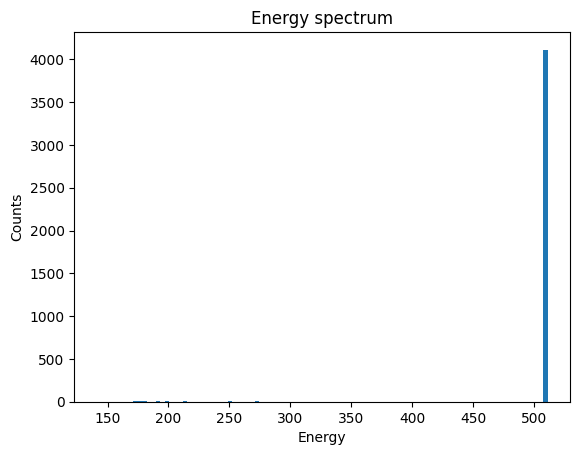

In [14]:
import uproot
import matplotlib.pyplot as plt

f = uproot.open("test.root")
tree = f[list(f.keys())[0]]

energy = tree["Gamma1_HitE1"].array(library="np")

plt.hist(energy, bins=100)
plt.xlabel("Energy")
plt.ylabel("Counts")
plt.title("Energy spectrum")
plt.show()

In [15]:
import numpy as np
f = uproot.open("test.root")
tree = f["NCS"]

g1 = tree["Gamma1_Theta"].array(library="np")
g2 = tree["Gamma2_Theta"].array(library="np")

print(np.mean(g1))
print(np.mean(g2))
print(np.allclose(g1, g2))

0.0
0.0
True


hit multiplicity

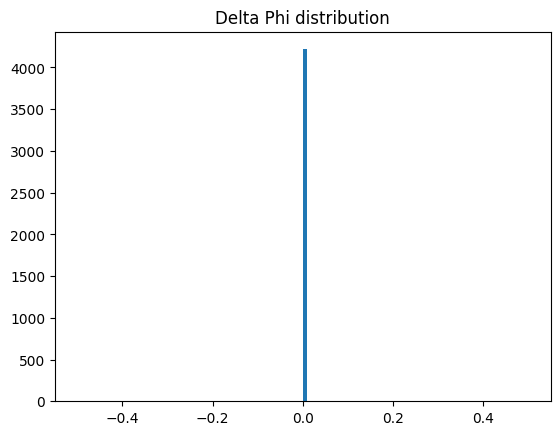

In [18]:
dphi = tree["DeltaPhi"].array(library="np")

plt.hist(dphi, bins=100)
plt.title("Delta Phi distribution")
plt.show()

In [19]:
print(g1[:20])
print(g2[:20])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [20]:
g1x = tree["Gamma1_HitX1"].array(library="np")
g2x = tree["Gamma2_HitX1"].array(library="np")

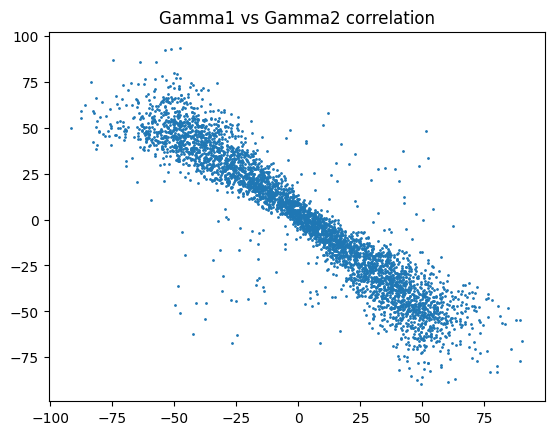

In [21]:
plt.scatter(g1x, g2x, s=1)
plt.title("Gamma1 vs Gamma2 correlation")
plt.show()

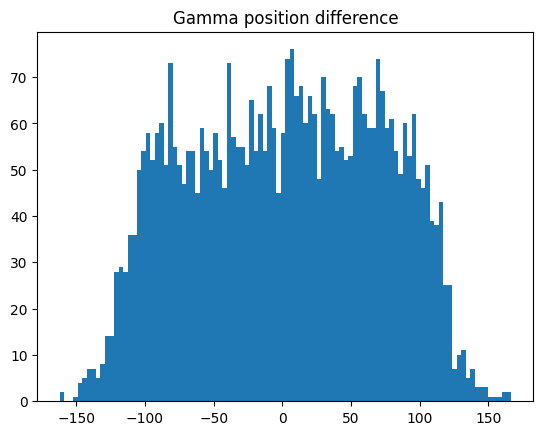

In [22]:
dx = g1x - g2x

plt.hist(dx, bins=100)
plt.title("Gamma position difference")
plt.show()

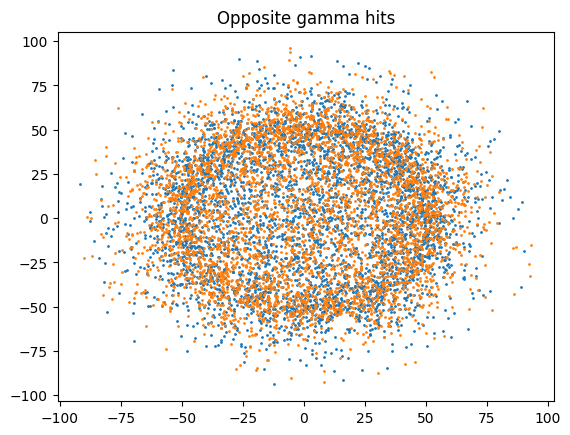

In [24]:
g1y = tree["Gamma1_HitY1"].array(library="np")
g2y = tree["Gamma2_HitY1"].array(library="np")

plt.scatter(g1x, g1y, s=1)
plt.scatter(g2x, g2y, s=1)
plt.title("Opposite gamma hits")
plt.show()

In [25]:
f = uproot.open("test.root")
tree = f["NCS"]

print(tree.keys())

['AnnihilX', 'AnnihilY', 'AnnihilZ', 'Gamma1_ScatterX', 'Gamma1_ScatterY', 'Gamma1_ScatterZ', 'Gamma1_Theta', 'Gamma1_HitE1', 'Gamma1_HitX1', 'Gamma1_HitY1', 'Gamma1_HitZ1', 'Gamma1_HitE2', 'Gamma1_HitX2', 'Gamma1_HitY2', 'Gamma1_HitZ2', 'Gamma2_ScatterX', 'Gamma2_ScatterY', 'Gamma2_ScatterZ', 'Gamma2_Theta', 'Gamma2_HitE1', 'Gamma2_HitX1', 'Gamma2_HitY1', 'Gamma2_HitZ1', 'Gamma2_HitE2', 'Gamma2_HitX2', 'Gamma2_HitY2', 'Gamma2_HitZ2', 'DeltaPhi']


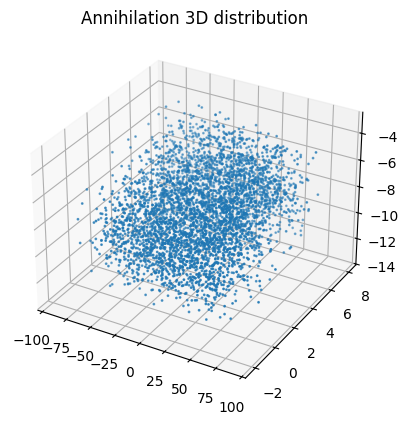

In [26]:
z = tree["AnnihilZ"].array(library="np")

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=1)

ax.set_title("Annihilation 3D distribution")
plt.show()

In [27]:
g1 = tree["Gamma1_Theta"].array(library="np")
g2 = tree["Gamma2_Theta"].array(library="np")

import numpy as np

print("Gamma1 mean:", np.mean(g1))
print("Gamma2 mean:", np.mean(g2))
print("Are identical:", np.allclose(g1, g2))

Gamma1 mean: 0.0
Gamma2 mean: 0.0
Are identical: True


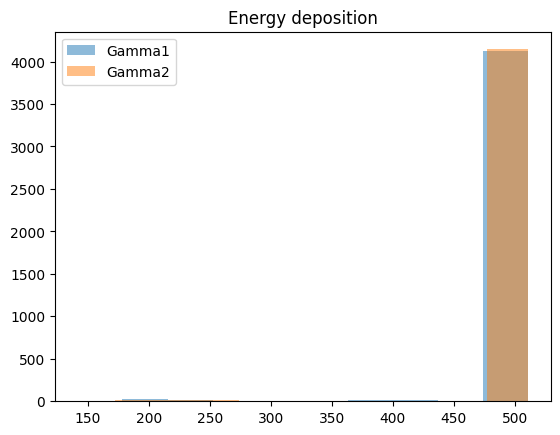

In [28]:
e1 = tree["Gamma1_HitE1"].array(library="np")
e2 = tree["Gamma2_HitE1"].array(library="np")

plt.hist(e1, bins=10, alpha=0.5, label="Gamma1")
plt.hist(e2, bins=10, alpha=0.5, label="Gamma2")
plt.legend()
plt.title("Energy deposition")
plt.show()

In [29]:
e1 = tree["Gamma1_HitE1"].array(library="np")

print(np.min(e1), np.max(e1))
print(np.unique(e1)[:10])

141.34605 510.9989
[141.34605 144.09645 154.52663 172.4548  173.59102 174.43774 175.43855
 177.51915 178.2817  178.98343]


In [30]:
print(np.mean(e1))
print(np.std(e1))
print(len(e1))

505.75095
36.608677
4218


In [31]:
print(np.corrcoef(e1, e2))

[[1.         0.01082905]
 [0.01082905 1.        ]]


In [33]:
!pip install hist
import uproot
import awkward as ak
import hist
from hist import Hist

file = uproot.open("test.root")
phantom_tree = file["PhantomSCS;1"].arrays()
scanner_tree = file["ScannerSCS;1"].arrays()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.9 MB/s eta 0:00:00


In [34]:
import uproot
import awkward as ak
import hist
from hist import Hist

file = uproot.open("test.root")
phantom_tree = file["PhantomSCS;1"].arrays()
scanner_tree = file["ScannerSCS;1"].arrays()

/usr/local/lib/python3.12/dist-packages/mplhep/_utils.py:1092: RuntimeWarning: divide by zero encountered in scalar divide
  return self.flat_scale(1 / np.sum(np.diff(self.edges_1d()) * self.values()))
/usr/local/lib/python3.12/dist-packages/mplhep/_utils.py:1075: RuntimeWarning: invalid value encountered in multiply
  self._values *= scale
/usr/local/lib/python3.12/dist-packages/mplhep/_utils.py:1076: RuntimeWarning: invalid value encountered in multiply
  self.yerr_lo *= scale
/usr/local/lib/python3.12/dist-packages/mplhep/_utils.py:1077: RuntimeWarning: invalid value encountered in multiply
  self.yerr_hi *= scale


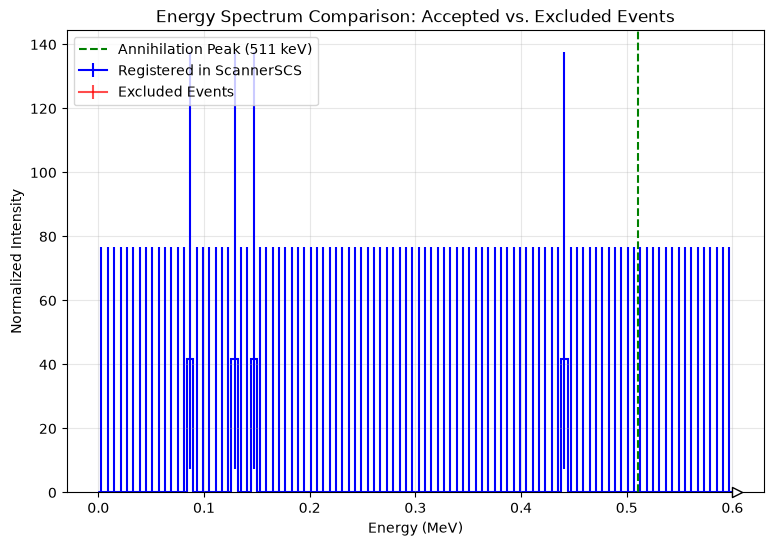

In [1]:
import uproot
import hist
import matplotlib.pyplot as plt

file = uproot.open("test.root")

# Inspect available keys in ScannerSCS;1 and Excluded;1
# print("Keys available in ScannerSCS;1:", file["ScannerSCS;1"].keys())
# print("Keys available in Excluded;1:", file["Excluded;1"].keys())

# Extract the energy branch using the correct name 'Gamma1_HitE1'
energy_accepted = file["ScannerSCS;1"].arrays("Gamma1_HitE1", library="np")["Gamma1_HitE1"]
energy_excluded = file["Excluded;1"].arrays("Gamma1_HitE1", library="np")["Gamma1_HitE1"]

# Constructing histograms using Scikit-HEP 'hist'
h_accepted = hist.Hist(hist.axis.Regular(100, 0, 0.6, name="E", label="Energy (MeV)"))
h_excluded = hist.Hist(hist.axis.Regular(100, 0, 0.6, name="E", label="Energy (MeV)"))

h_accepted.fill(E=energy_accepted)
h_excluded.fill(E=energy_excluded)

# Plotting overlays
plt.figure(figsize=(9, 6))

# Plot normalized profiles (density=True) to compare shapes easily
h_accepted.plot1d(label="Registered in ScannerSCS", color="blue", density=True)
h_excluded.plot1d(label="Excluded Events", color="red", alpha=0.7, density=True)

# PET specific line marker (0.511 MeV annihilation photon peak)
plt.axvline(x=0.511, color="green", linestyle="--", label="Annihilation Peak (511 keV)")

plt.title("Energy Spectrum Comparison: Accepted vs. Excluded Events")
plt.ylabel("Normalized Intensity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
print("Keys available in ScannerSCS;1:", file["ScannerSCS;1"].keys())
print("Keys available in Excluded;1:", file["Excluded;1"].keys())

Keys available in ScannerSCS;1: ['AnnihilX', 'AnnihilY', 'AnnihilZ', 'Gamma1_ScatterX', 'Gamma1_ScatterY', 'Gamma1_ScatterZ', 'Gamma1_Theta', 'Gamma1_HitE1', 'Gamma1_HitX1', 'Gamma1_HitY1', 'Gamma1_HitZ1', 'Gamma1_HitE2', 'Gamma1_HitX2', 'Gamma1_HitY2', 'Gamma1_HitZ2', 'Gamma2_ScatterX', 'Gamma2_ScatterY', 'Gamma2_ScatterZ', 'Gamma2_Theta', 'Gamma2_HitE1', 'Gamma2_HitX1', 'Gamma2_HitY1', 'Gamma2_HitZ1', 'Gamma2_HitE2', 'Gamma2_HitX2', 'Gamma2_HitY2', 'Gamma2_HitZ2', 'DeltaPhi']
Keys available in Excluded;1: ['AnnihilX', 'AnnihilY', 'AnnihilZ', 'Gamma1_ScatterX', 'Gamma1_ScatterY', 'Gamma1_ScatterZ', 'Gamma1_Theta', 'Gamma1_HitE1', 'Gamma1_HitX1', 'Gamma1_HitY1', 'Gamma1_HitZ1', 'Gamma1_HitE2', 'Gamma1_HitX2', 'Gamma1_HitY2', 'Gamma1_HitZ2', 'Gamma2_ScatterX', 'Gamma2_ScatterY', 'Gamma2_ScatterZ', 'Gamma2_Theta', 'Gamma2_HitE1', 'Gamma2_HitX1', 'Gamma2_HitY1', 'Gamma2_HitZ1', 'Gamma2_HitE2', 'Gamma2_HitX2', 'Gamma2_HitY2', 'Gamma2_HitZ2', 'DeltaPhi']


In [41]:
!pip install mplhep

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 109.4 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


line of response from hit one

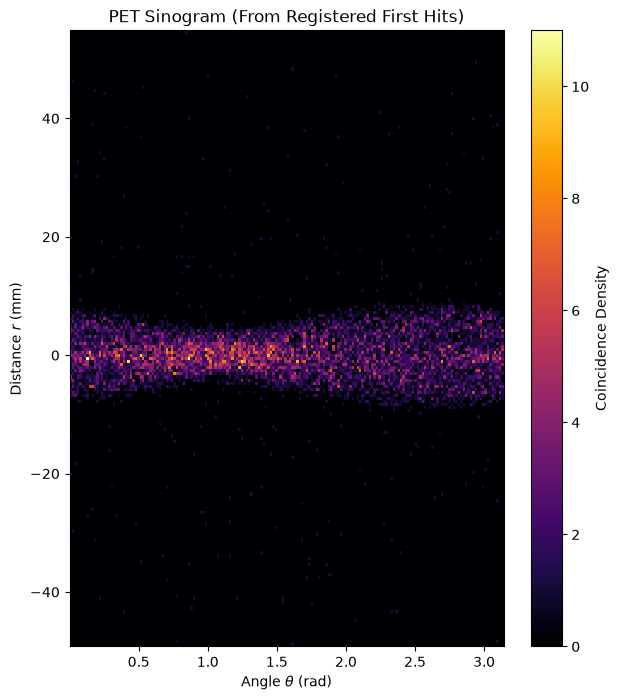

In [4]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

file = uproot.open("test.root")
tree = file["ScannerSCS;1"]

# Extract first hit locations for Gamma 1 and Gamma 2
data = tree.arrays(["Gamma1_HitX1", "Gamma1_HitY1", "Gamma2_HitX1", "Gamma2_HitY1"], library="np")
x1, y1 = data["Gamma1_HitX1"], data["Gamma1_HitY1"]
x2, y2 = data["Gamma2_HitX1"], data["Gamma2_HitY1"]

# Calculate the angle theta [0, pi] of the LOR
theta = np.mod(np.arctan2(y2 - y1, x2 - x1), np.pi)

# Calculate the perpendicular distance (r) from the origin to the LOR
r = (x1 * y2 - y1 * x2) / np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

# Plot the Raw Sinogram
plt.figure(figsize=(7, 8))
plt.hist2d(theta, r, bins=[180, 200], cmap='inferno')
plt.title("PET Sinogram (From Registered First Hits)")
plt.xlabel(r"Angle $\theta$ (rad)")
plt.ylabel("Distance $r$ (mm)")
plt.colorbar(label="Coincidence Density")
plt.show()

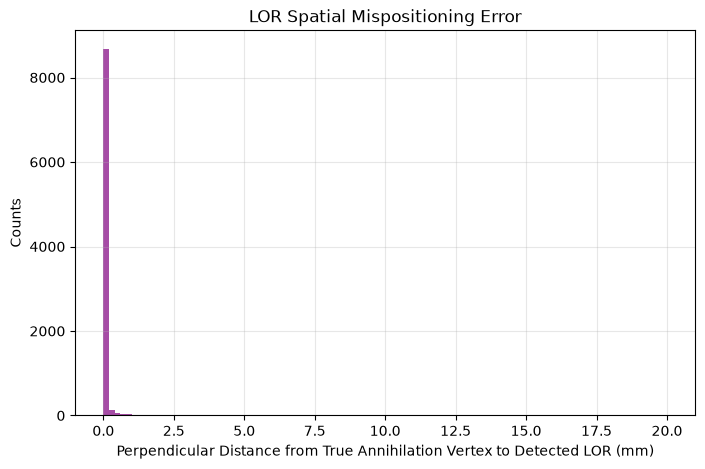

In [5]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

tree = uproot.open("test.root")["ScannerSCS;1"].arrays(library="np")

x0, y0 = tree["AnnihilX"], tree["AnnihilY"]
x1, y1 = tree["Gamma1_HitX1"], tree["Gamma1_HitY1"]
x2, y2 = tree["Gamma2_HitX1"], tree["Gamma2_HitY1"]

# Shortest distance from a point (x0, y0) to the line passing through (x1, y1) and (x2, y2)
numerator = np.abs((y2 - y1) * x0 - (x2 - x1) * y0 + x2 * y1 - y2 * x1)
denominator = np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
lor_error = numerator / (denominator + 1e-8)  # prevent division by zero

plt.figure(figsize=(8, 5))
plt.hist(lor_error, bins=100, range=(0, 20), color='purple', histtype='stepfilled', alpha=0.7)
plt.title("LOR Spatial Mispositioning Error")
plt.xlabel("Perpendicular Distance from True Annihilation Vertex to Detected LOR (mm)")
plt.ylabel("Counts")
plt.grid(True, alpha=0.3)
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_12708/1713778993.py:14: SyntaxWarning: invalid escape sequence '\D'
  plt.title("Acoplanarity Distribution ($\Delta\Phi$)")
/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


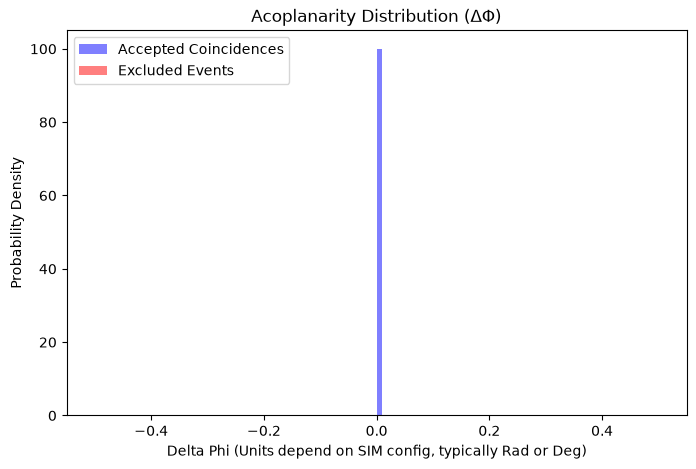

In [6]:
import uproot
import matplotlib.pyplot as plt

file = uproot.open("test.root")
dp_accepted = file["ScannerSCS;1"].arrays("DeltaPhi", library="np")["DeltaPhi"]
dp_excluded = file["Excluded;1"].arrays("DeltaPhi", library="np")["DeltaPhi"]

# Convert to degrees if your simulation saved them in radians
# dp_accepted = np.degrees(dp_accepted)

plt.figure(figsize=(8, 5))
plt.hist(dp_accepted, bins=100, alpha=0.5, label='Accepted Coincidences', density=True, color='blue')
plt.hist(dp_excluded, bins=100, alpha=0.5, label='Excluded Events', density=True, color='red')
plt.title("Acoplanarity Distribution ($\Delta\Phi$)")
plt.xlabel("Delta Phi (Units depend on SIM config, typically Rad or Deg)")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

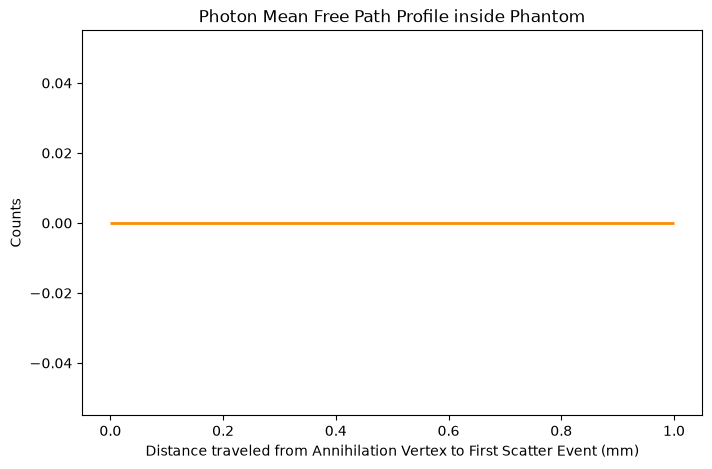

In [7]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

tree = uproot.open("test.root")["ScannerSCS;1"].arrays(library="np")

# Filter events where a phantom scatter actually occurred
# (Assuming 0 means no scatter occurred. Adjust if your sim uses a distinct flag value)
scattered_mask = (tree["Gamma1_ScatterX"] != 0) & (tree["Gamma1_ScatterY"] != 0)

ax = tree["AnnihilX"][scattered_mask]
ay = tree["AnnihilY"][scattered_mask]
sx = tree["Gamma1_ScatterX"][scattered_mask]
sy = tree["Gamma1_ScatterY"][scattered_mask]

# Calculate tracking path length before the first scatter event
dist_to_scatter = np.sqrt((sx - ax)**2 + (sy - ay)**2)

plt.figure(figsize=(8, 5))
plt.hist(dist_to_scatter, bins=100, color='darkorange', histtype='step', lw=2)
plt.title("Photon Mean Free Path Profile inside Phantom")
plt.xlabel("Distance traveled from Annihilation Vertex to First Scatter Event (mm)")
plt.ylabel("Counts")
plt.show()